# 06 — Reservoir ensemble and history-match agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/AI/community_agent_demos/06_reservoir_ensemble_history_match_agent.ipynb)

Update a probabilistic tank-model ensemble with production history and propagate uncertainty to facility demand.

This is a **synthetic public demonstration**, not an autonomous-control
system. The agent prepares a traceable engineering screening package;
a qualified engineer owns assumptions, validation, and decisions.


## Agent contract

**Inputs:** ensemble parameters, pressure/rate history, observation
uncertainty, and facility boundary conditions. **Outputs:** posterior
weights, forecast percentiles, influential parameters, and facility
load distributions.

Gaussian observation likelihood is
$w_i\propto\exp[-\frac12\sum_t((y_t-f_i(t))/\sigma_t)^2]$.

Deep dive: [ERT and NeqSim field development](../../reservoir/ert_neqsim_integrated_field_development.ipynb).


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "scipy": "1.18.0",
}
install_specs = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = version(package_name)
    except PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        install_specs.append(f"{package_name}=={required_version}")

if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
RUNTIME_DEPENDENCY_JAR = os.environ.get("NEQSIM_RUNTIME_DEPENDENCY_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
    SOURCE_BUILD_KIND = os.environ.get(
        "NEQSIM_SOURCE_BUILD_KIND", "prebuilt source JAR override"
    )
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]
    SOURCE_BUILD_KIND = "Maven package from current master"

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-agent-demo-matplotlib")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
if RUNTIME_DEPENDENCY_JAR:
    jpype.addClassPath(str(Path(RUNTIME_DEPENDENCY_JAR).resolve()))
from neqsim.neqsimpython import init_jvm


init_jvm()
SOURCE_PROBE = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
DESIGN_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
DESIGN_JAR_LOCATION = str(
    DESIGN_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION
assert SOURCE_JAR.name in DESIGN_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Source build: {SOURCE_BUILD_KIND}")
print(f"Loaded thermodynamics from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.17.0
NeqSim source ref: master
NeqSim source commit: 1dee5b51f6689d0b383e8d90fece9729132dd6e3
NeqSim source JAR SHA-256: f3e4080d8e6a97225047de1ec04c5a7fcd1049845b770a11da4986d96d2dce8c
Source build: javac source overlay from exact master Java sources
Loaded thermodynamics from: file:/workspace/scratch/6d0c0fad8be4/neqsim-master/target/neqsim-current-master-agent-demo-complete.jar
Python runtime: 3.12.13


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from IPython.display import display
from neqsim.thermo import TPflash, fluid


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})
RNG = np.random.default_rng(42)


def flash_state(composition, pressure_bara, temperature_c, model="srk"):
    """Return a compact, unit-labelled NeqSim flash result."""
    system = fluid(model)
    for component, fraction in composition.items():
        system.addComponent(component, float(fraction))
    system.setMixingRule(2)
    system.setMultiPhaseCheck(True)
    system.setPressure(float(pressure_bara), "bara")
    system.setTemperature(float(temperature_c), "C")
    TPflash(system)
    system.initProperties()
    phases = []
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        phases.append(
            {
                "phase": str(phase.getPhaseTypeName()),
                "beta_mol": float(phase.getBeta()),
                "density_kg_m3": float(phase.getDensity("kg/m3")),
            }
        )
    return {
        "system": system,
        "pressure_bara": pressure_bara,
        "temperature_c": temperature_c,
        "density_kg_m3": float(system.getDensity("kg/m3")),
        "viscosity_pa_s": float(system.getViscosity("kg/msec")),
        "z_factor": float(system.getZ()),
        "molar_mass_kg_mol": float(system.getMolarMass("kg/mol")),
        "cp_j_kg_k": float(system.getCp("J/kgK")),
        "cv_j_kg_k": float(system.getCv("J/kgK")),
        "phases": phases,
    }


NORTHSTAR_GAS = {
    "methane": 0.820,
    "ethane": 0.075,
    "propane": 0.035,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "n-heptane": 0.020,
    "CO2": 0.015,
    "nitrogen": 0.010,
}


In [3]:
standard_state = flash_state(NORTHSTAR_GAS, 1.01325, 15.0)
separator_state = flash_state(NORTHSTAR_GAS, 70.0, 35.0)
print(f"Standard gas density={standard_state['density_kg_m3']:.3f} kg/m3")
print(f"Separator Z={separator_state['z_factor']:.3f}")


Standard gas density=0.906 kg/m3
Separator Z=0.830


In [4]:
n_ensemble = 450
years = np.arange(0.0, 16.0)
giip = RNG.lognormal(np.log(118.0), 0.23, n_ensemble)
aquifer = RNG.uniform(0.05, 0.55, n_ensemble)
productivity = RNG.lognormal(np.log(0.085), 0.20, n_ensemble)
facility_pressure = 78.0
p_initial = 260.0

def simulate_member(giip_bsm3, aquifer_strength, pi):
    depletion = (1.0 - np.exp(-years / 7.5))
    pressure = p_initial - 150.0 * depletion * (115.0 / giip_bsm3)
    pressure += 48.0 * aquifer_strength * depletion
    rate = np.minimum(12.0, np.maximum(pressure - facility_pressure, 0.0) * pi)
    return pressure, rate

pressures = np.empty((n_ensemble, years.size))
rates = np.empty_like(pressures)
for index in range(n_ensemble):
    pressures[index], rates[index] = simulate_member(
        giip[index], aquifer[index], productivity[index]
    )

truth_pressure, truth_rate = simulate_member(126.0, 0.32, 0.091)
history_mask = years <= 6.0
observed_pressure = truth_pressure[history_mask] + RNG.normal(0.0, 2.0, history_mask.sum())
observed_rate = truth_rate[history_mask] + RNG.normal(0.0, 0.18, history_mask.sum())


In [5]:
pressure_error = (pressures[:, history_mask] - observed_pressure) / 2.0
rate_error = (rates[:, history_mask] - observed_rate) / 0.18
log_weight = -0.5 * np.sum(pressure_error**2 + rate_error**2, axis=1)
weights = np.exp(log_weight - log_weight.max())
weights /= weights.sum()

def weighted_quantile(values, quantiles, sample_weight):
    order = np.argsort(values)
    sorted_values = np.asarray(values)[order]
    cumulative = np.cumsum(np.asarray(sample_weight)[order])
    return np.interp(quantiles, cumulative, sorted_values)

posterior = pd.DataFrame(
    {
        "parameter": ["GIIP [billion Sm3]", "aquifer strength", "productivity"],
        "prior_p50": [np.median(giip), np.median(aquifer), np.median(productivity)],
        "posterior_p10": [
            weighted_quantile(giip, [0.10], weights)[0],
            weighted_quantile(aquifer, [0.10], weights)[0],
            weighted_quantile(productivity, [0.10], weights)[0],
        ],
        "posterior_p50": [
            weighted_quantile(giip, [0.50], weights)[0],
            weighted_quantile(aquifer, [0.50], weights)[0],
            weighted_quantile(productivity, [0.50], weights)[0],
        ],
        "posterior_p90": [
            weighted_quantile(giip, [0.90], weights)[0],
            weighted_quantile(aquifer, [0.90], weights)[0],
            weighted_quantile(productivity, [0.90], weights)[0],
        ],
    }
)
display(posterior)

forecast_percentiles = np.vstack(
    [
        weighted_quantile(rates[:, index], [0.10, 0.50, 0.90], weights)
        for index in range(years.size)
    ]
)
peak_mass_rate = (
    forecast_percentiles[:, 2].max() * 1e9 / (365.25 * 86400.0)
)
peak_mass_rate *= standard_state["density_kg_m3"]
print(f"Posterior P90 facility feed={peak_mass_rate:.1f} kg/s")


Posterior P90 facility feed=344.6 kg/s


,parameter,prior_p50,posterior_p10,posterior_p50,posterior_p90
0,GIIP [billion Sm3],117.931682,119.462038,122.063545,128.725103
1,aquifer strength,0.295872,0.201963,0.404962,0.420496
2,productivity,0.085196,0.091297,0.091452,0.093254


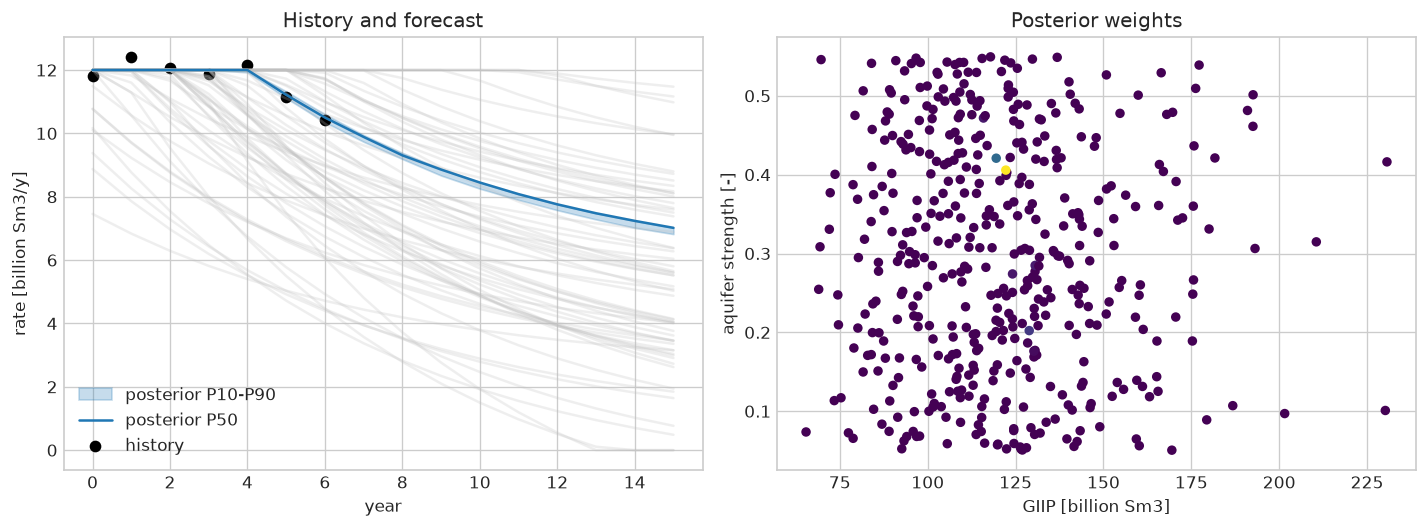

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for index in RNG.choice(n_ensemble, 60, replace=False):
    axes[0].plot(years, rates[index], color="0.75", alpha=0.25)
axes[0].fill_between(
    years,
    forecast_percentiles[:, 0],
    forecast_percentiles[:, 2],
    color="tab:blue",
    alpha=0.25,
    label="posterior P10-P90",
)
axes[0].plot(years, forecast_percentiles[:, 1], color="tab:blue", label="posterior P50")
axes[0].scatter(years[history_mask], observed_rate, color="black", label="history")
axes[0].set(xlabel="year", ylabel="rate [billion Sm3/y]", title="History and forecast")
axes[0].legend()
axes[1].scatter(giip, aquifer, c=weights, cmap="viridis", s=22)
axes[1].set(xlabel="GIIP [billion Sm3]", ylabel="aquifer strength [-]", title="Posterior weights")
plt.tight_layout()
plt.show()


In [7]:
giip_p50 = posterior.loc[posterior.parameter.str.startswith("GIIP"), "posterior_p50"].iloc[0]
assert abs(giip_p50 - 126.0) < 15.0
assert np.isclose(weights.sum(), 1.0)
assert peak_mass_rate > 50.0
print("VALIDATION PASSED")
print("Recommendation: preserve the ensemble and pass P10/P50/P90 rates to facilities.")


VALIDATION PASSED
Recommendation: preserve the ensemble and pass P10/P50/P90 rates to facilities.


## Interpretation and limits

History concentrates probability around plausible GIIP and aquifer
combinations, while retaining forecast uncertainty for facilities.
This compact tank model demonstrates the contract; real studies need
simulator-specific physics, correlated errors, localization, and
independent geological plausibility checks.
